# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

expressoes = np.random.normal(0, 2, 1000)

gene_names = [f"gene_{i}" for i in range(1, 1001)]

df_expressoes = pd.DataFrame(expressoes, index=gene_names, columns=['Nível_Expressao'])

print(df_expressoes.head())

        Nível_Expressao
gene_1         1.499347
gene_2         4.606670
gene_3        -2.296340
gene_4         0.787552
gene_5         0.806479


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
import numpy as np
import pandas as pd

pacientes = np.random.randint(-50, 51, 1000)
pacient_names = [f"paciente_{i}" for i in range(1, 1001)]

dados_combinados = {
    'Expressao_genes': expressoes,
    'Genes_diferencialmente_expressos': pacientes
}

df_final = pd.DataFrame(dados_combinados, index=pacient_names)

print(df_final.head())

            Expressao_genes  Genes_diferencialmente_expressos
paciente_1         1.499347                               -36
paciente_2         4.606670                                26
paciente_3        -2.296340                                -7
paciente_4         0.787552                                40
paciente_5         0.806479                               -28


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.:

In [3]:
import pandas as pd

df_final['Categoria_Pacientes'] = pd.cut(df_final['Genes_diferencialmente_expressos'], bins=6)

print("Criterios de Grupos (intervalos):")
print (df_final['Categoria_Pacientes'].unique().sort_values())

print("\DataFrame Categorizado:")
print(df_final.head(10))

Criterios de Grupos (intervalos):
[(-50.1, -33.333], (-33.333, -16.667], (-16.667, 0.0], (0.0, 16.667], (16.667, 33.333], (33.333, 50.0]]
Categories (6, interval[float64, right]): [(-50.1, -33.333] < (-33.333, -16.667] < (-16.667, 0.0] <
                                           (0.0, 16.667] < (16.667, 33.333] < (33.333, 50.0]]
\DataFrame Categorizado:
             Expressao_genes  Genes_diferencialmente_expressos  \
paciente_1          1.499347                               -36   
paciente_2          4.606670                                26   
paciente_3         -2.296340                                -7   
paciente_4          0.787552                                40   
paciente_5          0.806479                               -28   
paciente_6          0.953954                                20   
paciente_7         -1.138811                               -16   
paciente_8         -1.589639                                13   
paciente_9         -1.346054                     

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_862/1710541762.py:8: SyntaxWarning: invalid escape sequence '\D'
  print("\DataFrame Categorizado:")


In [ ]:
Utilizei critério de Intervalos de mesma largura, pois vi que é um método útil para separar pacientes em níveis de resposta e ser mais fácil de analisar os dados.

## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [16]:
import pandas as pd
def criar_tabela_frequencia(serie):
    contagem = serie.value_counts(bins=10).sort_index()

    tabela= pd.DataFrame({
      'frequencia absoluta': contagem.values,
      'frequencia relativa': contagem.values / len(serie)
    }, index=contagem.index)

    return tabela

tabela_ex1 = criar_tabela_frequencia(df_final['Expressao_genes'])
tabela_ex2 = criar_tabela_frequencia(df_final['Genes_diferencialmente_expressos'])

print("Tabela de Frequência - Exercício 1:")
print(tabela_ex1)
print("\nTabela de Frequência - Exercício 2:")
print(tabela_ex2)

Tabela de Frequência - Exercício 1:
                  frequencia absoluta  frequencia relativa
(-6.453, -5.246]                    3                0.003
(-5.246, -4.052]                   12                0.012
(-4.052, -2.859]                   60                0.060
(-2.859, -1.665]                  126                0.126
(-1.665, -0.472]                  190                0.190
(-0.472, 0.722]                   244                0.244
(0.722, 1.916]                    184                0.184
(1.916, 3.109]                    112                0.112
(3.109, 4.303]                     53                0.053
(4.303, 5.496]                     16                0.016

Tabela de Frequência - Exercício 2:
                  frequencia absoluta  frequencia relativa
(-50.101, -40.0]                  101                0.101
(-40.0, -30.0]                    103                0.103
(-30.0, -20.0]                    117                0.117
(-20.0, -10.0]                    102     

## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

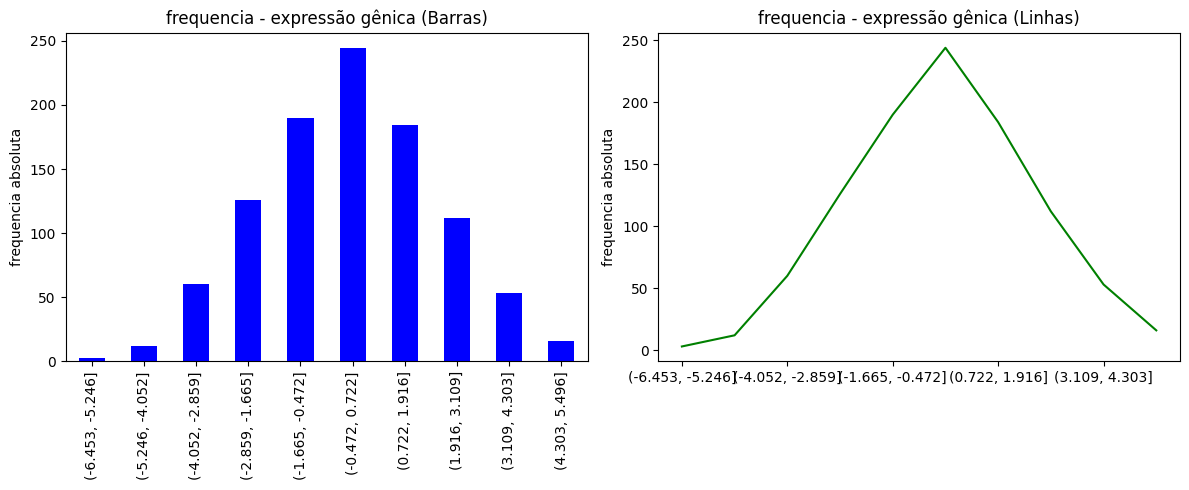

In [19]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
tabela_ex1['frequencia absoluta'].plot(kind='bar', color='blue')
plt.title('frequencia - expressão gênica (Barras)')
plt.ylabel('frequencia absoluta')

plt.subplot(1, 2, 2)
tabela_ex1['frequencia absoluta'].plot(kind='line', color='green')
plt.title('frequencia - expressão gênica (Linhas)')
plt.ylabel('frequencia absoluta')

plt.tight_layout()
plt.show()


### Número

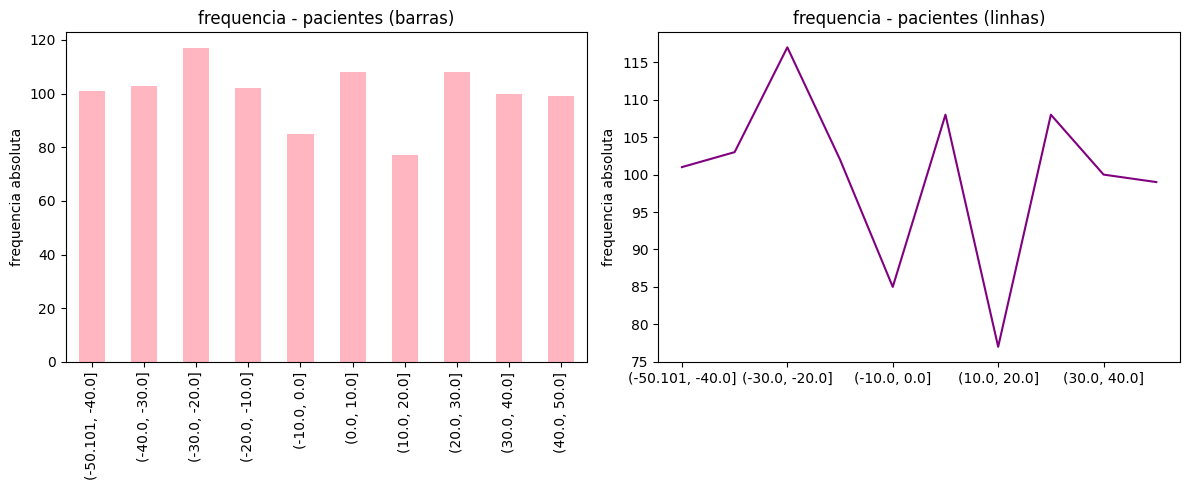

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
tabela_ex2['frequencia absoluta'].plot(kind='bar', color='lightpink')
plt.title('frequencia - pacientes (barras)')
plt.ylabel('frequencia absoluta')

plt.subplot(1, 2, 2)
tabela_ex2['frequencia absoluta'].plot(kind='line', color='purple')
plt.title('frequencia - pacientes (linhas)')
plt.ylabel('frequencia absoluta')

plt.tight_layout()
plt.show()


## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

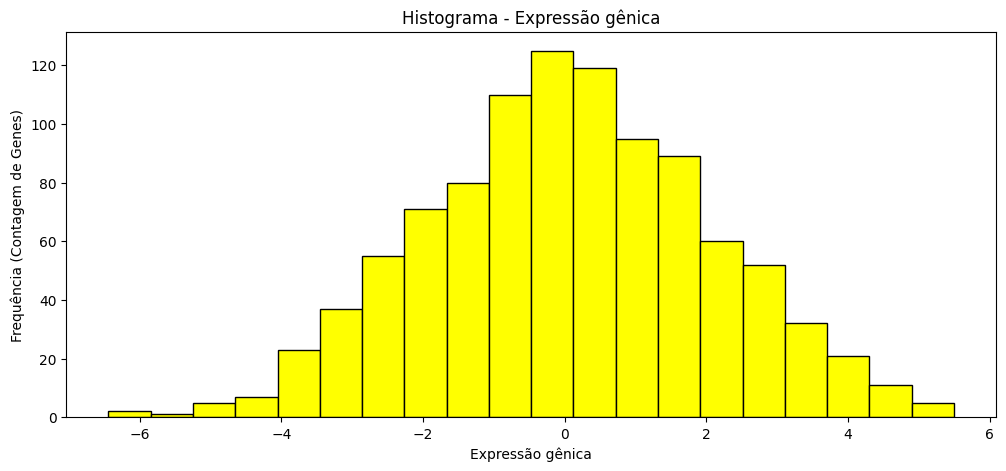

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(df_final['Expressao_genes'], bins=20, color='yellow', edgecolor='black')

plt.title('Histograma - Expressão gênica')
plt.xlabel('Expressão gênica')
plt.ylabel('Frequência (Contagem de Genes)')


plt.show()

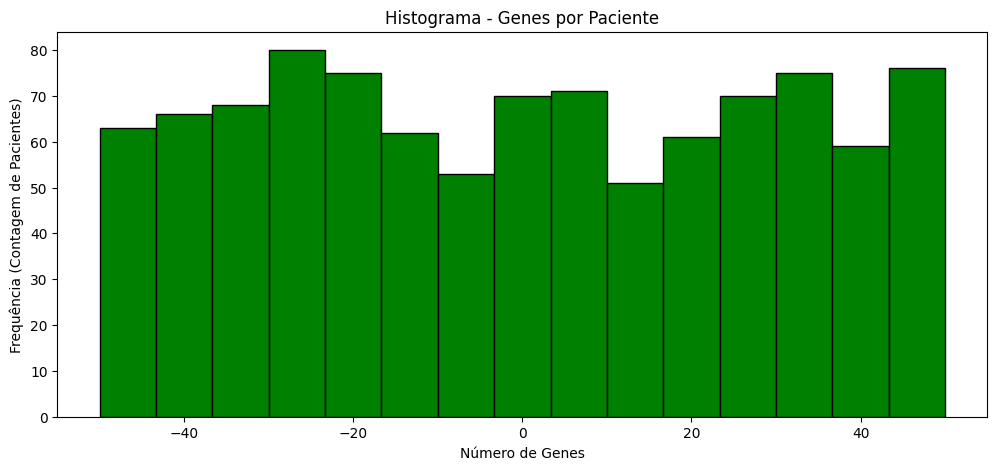

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(df_final['Genes_diferencialmente_expressos'], bins=15, color='green', edgecolor='black')

plt.title('Histograma - Genes por Paciente')
plt.xlabel('Número de Genes')
plt.ylabel('Frequência (Contagem de Pacientes)')

plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

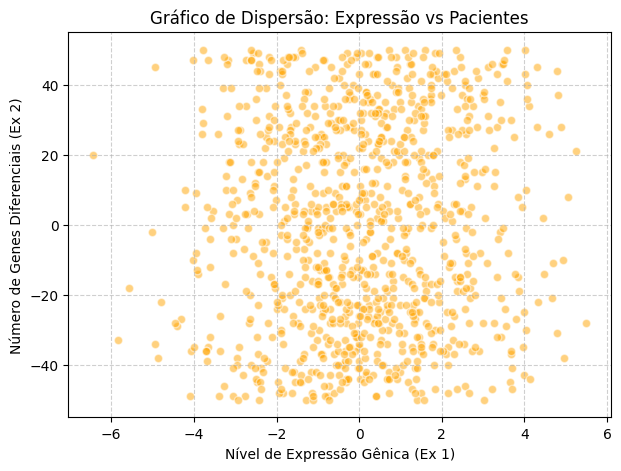

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize = (7,5))

plt.scatter(df_final['Expressao_genes'], df_final['Genes_diferencialmente_expressos'],
            alpha=0.5, color='orange', edgecolors='white')
plt.title('Gráfico de Dispersão: Expressão vs Pacientes')
plt.xlabel('Nível de Expressão Gênica (Ex 1)')
plt.ylabel('Número de Genes Diferenciais (Ex 2)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

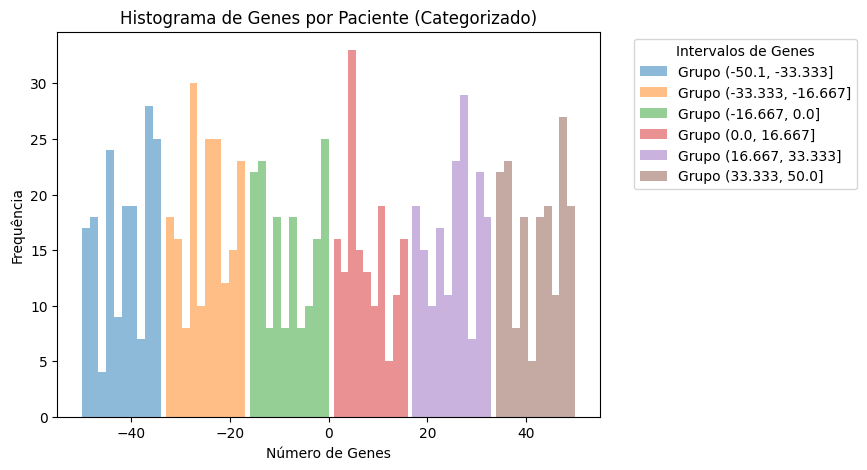

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

categorias = df_final['Categoria_Pacientes'].unique().sort_values()

for cat in categorias:
  dados_filtrados = df_final[df_final['Categoria_Pacientes'] == cat]
  plt.hist(dados_filtrados['Genes_diferencialmente_expressos'],
             bins=10, alpha=0.5, label=f'Grupo {cat}')

plt.title('Histograma de Genes por Paciente (Categorizado)')
plt.xlabel('Número de Genes')
plt.ylabel('Frequência')
plt.legend(title="Intervalos de Genes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

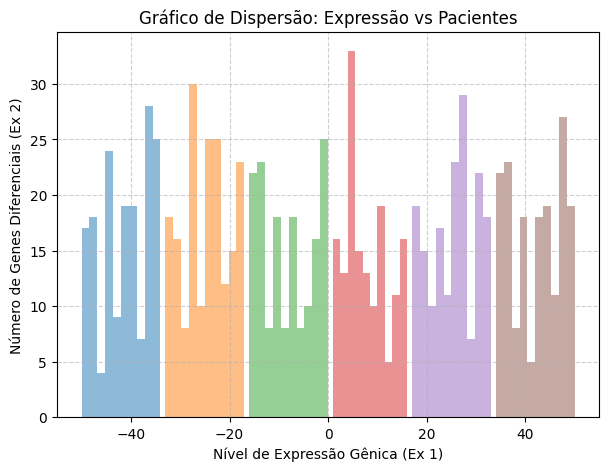

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize = (7,5))

categorias = df_final['Categoria_Pacientes'].unique().sort_values()

for cat in categorias:
  dados_filtrados = df_final[df_final['Categoria_Pacientes'] == cat]
  plt.hist(dados_filtrados['Genes_diferencialmente_expressos'],
             bins=10, alpha=0.5, label=f'Grupo {cat}')

plt.title('Gráfico de Dispersão: Expressão vs Pacientes')
plt.xlabel('Nível de Expressão Gênica (Ex 1)')
plt.ylabel('Número de Genes Diferenciais (Ex 2)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

In [ ]:
Discreta
contínua
ordinal
contínua
contínua
Discreta
contínua
Nominal
Nominal